Iteration 1, loss = 0.38400496
Iteration 2, loss = 0.35358846
Iteration 3, loss = 0.35199504
Iteration 4, loss = 0.35156947
Iteration 5, loss = 0.35078730
Iteration 6, loss = 0.35033761
Iteration 7, loss = 0.35023658
Iteration 8, loss = 0.35002888
Iteration 9, loss = 0.34971945
Iteration 10, loss = 0.34951052
Iteration 11, loss = 0.34943485
Iteration 12, loss = 0.34933394
Iteration 13, loss = 0.34911648
Iteration 14, loss = 0.34899681
Iteration 15, loss = 0.34894625
Iteration 16, loss = 0.34881578
Iteration 17, loss = 0.34881593
Iteration 18, loss = 0.34854539
Iteration 19, loss = 0.34856364
Iteration 20, loss = 0.34847602
Iteration 21, loss = 0.34848194
Iteration 22, loss = 0.34842475
Iteration 23, loss = 0.34843605
Iteration 24, loss = 0.34826455
Iteration 25, loss = 0.34814581
Iteration 26, loss = 0.34815533
Iteration 27, loss = 0.34790731
Iteration 28, loss = 0.34799884
Iteration 29, loss = 0.34775117
Iteration 30, loss = 0.34772144
Iteration 31, loss = 0.34772617
Iteration 32, los

c:\Users\laure\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92     42741
           1       0.58      0.18      0.28      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.58      0.60     50736
weighted avg       0.82      0.85      0.82     50736



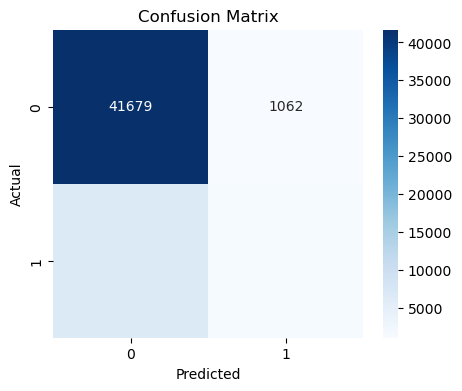

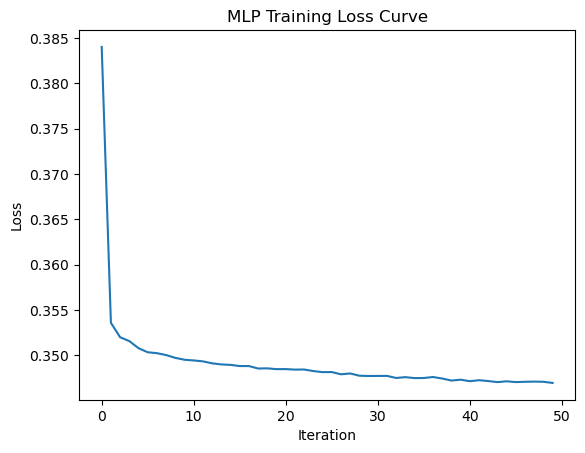

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

binary_cols = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost',
    'DiffWalk','Sex'
]
ordinal_cols = ['Age','Education','Income']
continuous_cols = ['BMI']
target_col = 'Diabetes_binary'

# Convert types
df[binary_cols + ordinal_cols + ['Diabetes_012']] = df[binary_cols + ordinal_cols + ['Diabetes_012']].astype('int8')

# Cap BMI and create binary target
df['BMI'] = df['BMI'].clip(10, 80)
df['Diabetes_binary'] = (df['Diabetes_012'] > 0).astype('int8')

# Features and target
X = df[binary_cols + ordinal_cols + continuous_cols]
y = df[target_col]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize BMI
scaler = StandardScaler()
X_train[['BMI']] = scaler.fit_transform(X_train[['BMI']])
X_test[['BMI']] = scaler.transform(X_test[['BMI']])


# Train neural network
mlp = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu',
                    solver='adam', max_iter=20, random_state=42, verbose=True)

mlp.fit(X_train, y_train)

# Evaluate model
y_pred = mlp.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Training loss curve
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()